# Prac 04

For this homework you are going to implement a lane line detector. Lane line detection is crucial for ADAS (Advanced Driver Assistance Systems) systems and, in particular, for LKA (Lane Keep Assist). You will use a [picture](https://en.wikipedia.org/wiki/Lane_departure_warning_system) from a front facing camera (mounted on the car) and will implement the following steps:
* Convert image to gray scale
* Compute edge map
* Apply Hough transform to obtain line parametrizations

In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [2]:
def create_lines(image: np.ndarray, lines: np.ndarray, edges: np.ndarray, color: int = 255, thickness: int = 1, line_type: int = cv2.LINE_AA):  #-> np.ndarray
    result = np.copy(image)

    h, w = image.shape[:2]
    diag = int(np.sqrt(h**2 + w**2))

    for line in lines:
        rho = line[0]
        theta = line[1]
        
        a = math.cos(theta)
        b = math.sin(theta)
        
        x0 = a * rho
        y0 = b * rho
        
        pt1 = (int(x0 + diag*(-b)), int(y0 + diag*(a)))
        pt2 = (int(x0 - diag*(-b)), int(y0 - diag*(a)))
        
        cv2.line(result, pt1, pt2, color, thickness, line_type)

    images = [edges, result]
    names = ['Edge map', 'Hough lines']
    fig, axes = plt.subplots(1, len(images))

    for index in range(len(images)):
        axes[index].imshow(images[index], cmap='gray')
        if index < len(names):
            axes[index].set_title(names[index])
    
    plt.show()
    # return result

Let's load and show the camera frame.

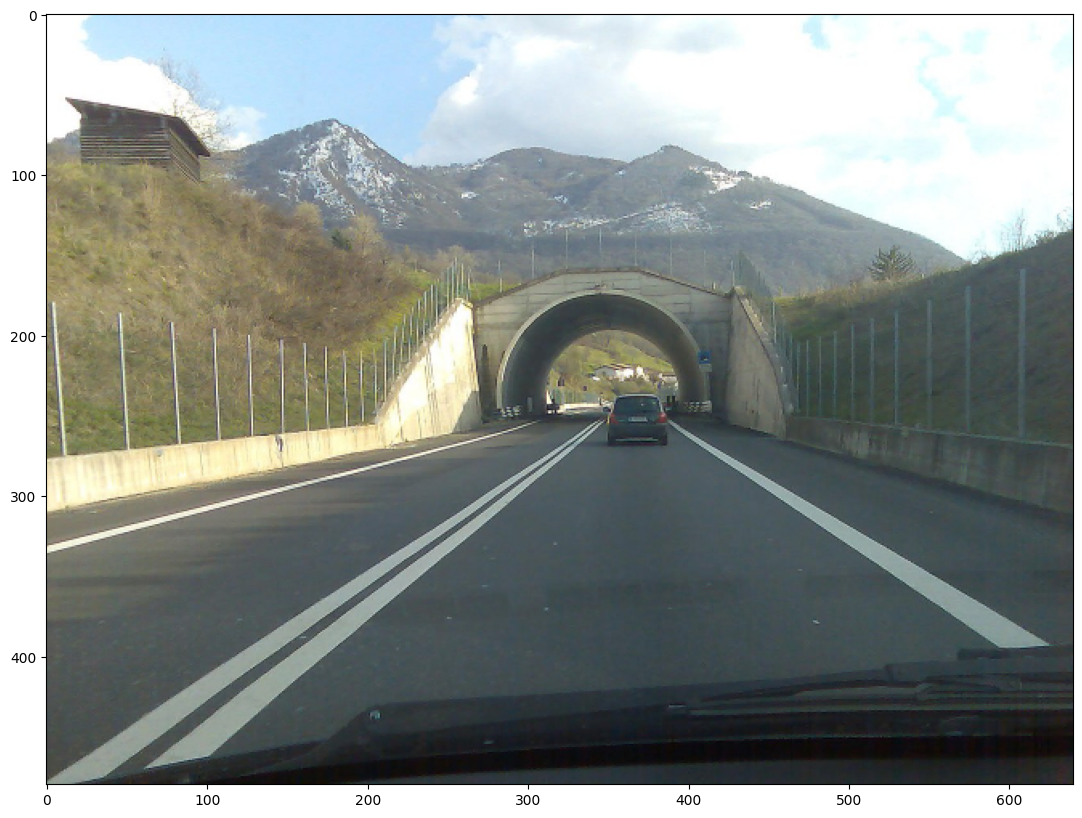

In [3]:
img = cv2.imread('Strada.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, None, fx=0.5, fy=0.5)
plt.imshow(img)

In [4]:
# Convert image to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

(<Axes: title={'center': 'Edge map'}>,
 Text(0.5, 1.0, 'Edge map'))

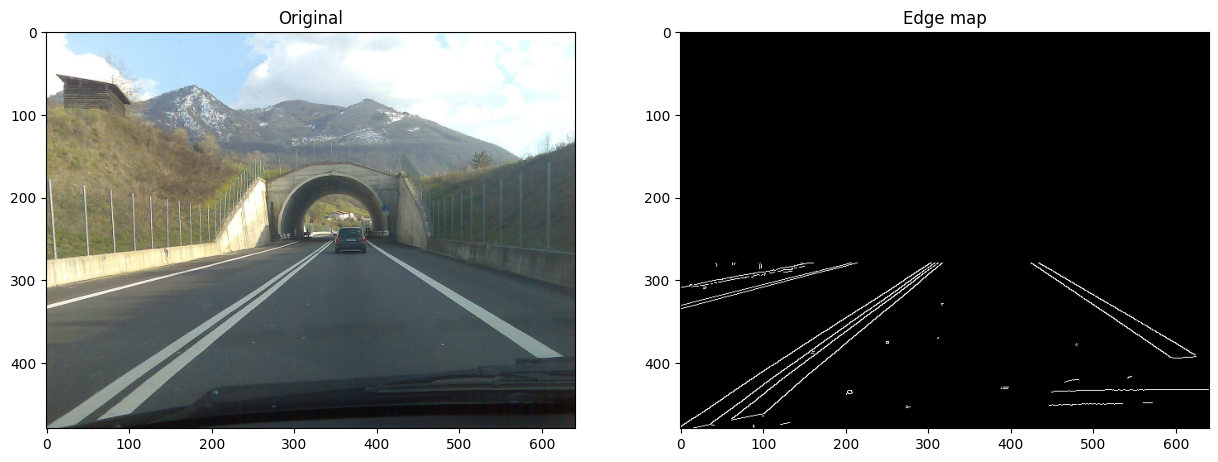

In [5]:
# Obtain edge map
# Hint: you can use Canny edge detector with th_low = 100, th_high = 150
# edges = cv2.Canny(gray, threshold1=100, threshold2=550)
# edges = cv2.Canny(gray, threshold1=100, threshold2=350)
edges = cv2.Canny(gray, threshold1=100, threshold2=150)

# We are only interseted in the road so we will remove everything above the horizon
edges[0:280] = 0
# edges[0:350] = 0

# Let's plot the images
plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(edges, cmap='gray'), plt.title('Edge map')

In [6]:
# Apply Hough transform to parametrize the lines
# Hint 1: Offset resolution of 2 pixels and slope resolution of 2 degrees work well in this case
# Hint 2: A suitable value for the accumulator threshold is 190
# lines = cv2.HoughLines(edges, rho=1, theta=2*np.pi/180, threshold=50)
lines = cv2.HoughLines(edges, rho=2, theta=2*np.pi/180, threshold=190)

# Let's get rid of the unnecessary dimension
lines = lines[:, 0, :]
print(f"[LINES]\n{lines}")


[LINES]
[[417.           0.87266463]
 [407.           0.9075712 ]
 [405.           0.94247776]
 [ 25.           2.0943952 ]
 [ -7.           2.1642082 ]
 [399.           1.012291  ]
 [411.           0.94247776]]


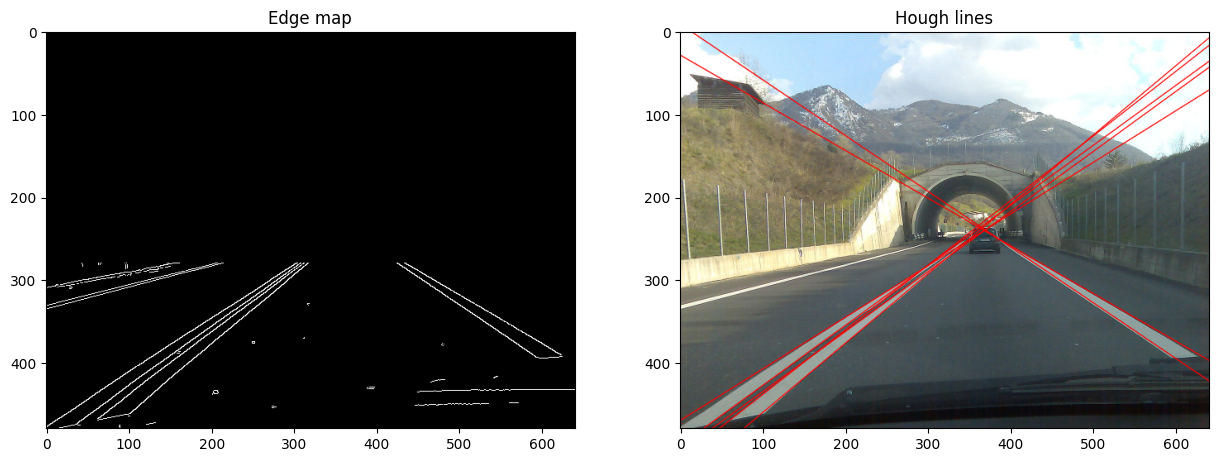

In [7]:
# Plot the resulting Hough lines
create_lines(img, lines, edges)

The edge map looks good but the Hough lines are too noisy. Let's clean the Hough lines first by removing all lines that we know cannot represent a lane line. In other words, all lines that are approximately horizontal shall be removed. Remember that horizontal lines correspond to theta = 90 degrees.

In [8]:
# Filter out all lines that are approximately horizontal (+/- 20 degrees). 
filtered_lines = []
for line in lines:
    # Extract theta for current line (remember Hough works with radians)
    theta = np.pi/2
    # Keep line if theta is not horizontal
    if line[1] != theta:
        filtered_lines.append(line)

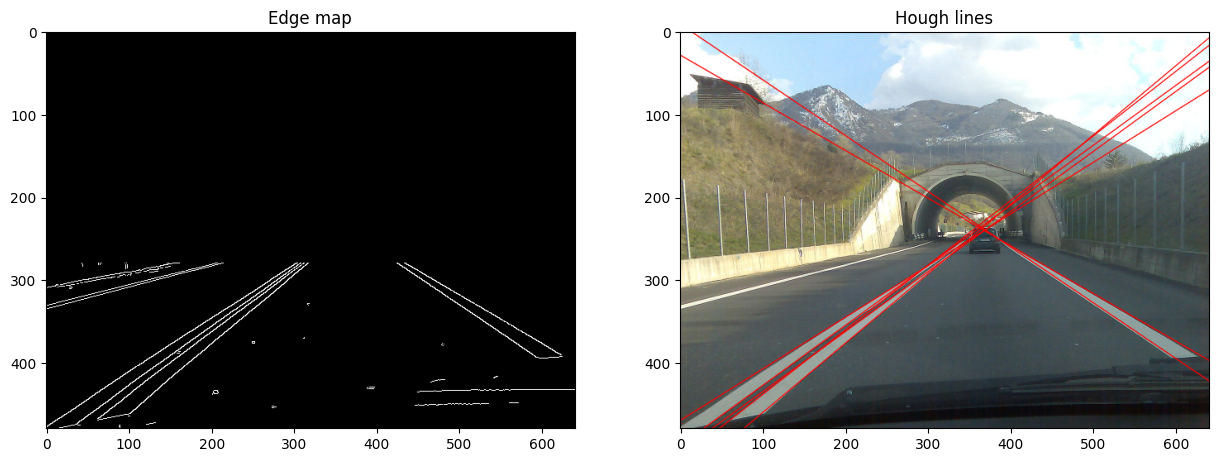

In [9]:
# Let's plot the resulting filtered lines
create_lines(img, filtered_lines, edges)

The result is now much better, but still we see some very similar lines. How can we get rid of them?
* Let's apply k-means clustering. It will find the clusters of the 6 we see in the picture lines and use the averages.

In [10]:
# We will apply k-means clustering to refine the detected lines.
# Don't worry, we will learn about the clustering later in the course :-)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6).fit(filtered_lines)
kmeans.cluster_centers_

array([[406.        ,   0.92502448],
       [ 25.        ,   2.09439516],
       [ -7.        ,   2.16420817],
       [417.        ,   0.87266463],
       [399.        ,   1.01229095],
       [411.        ,   0.94247776]])

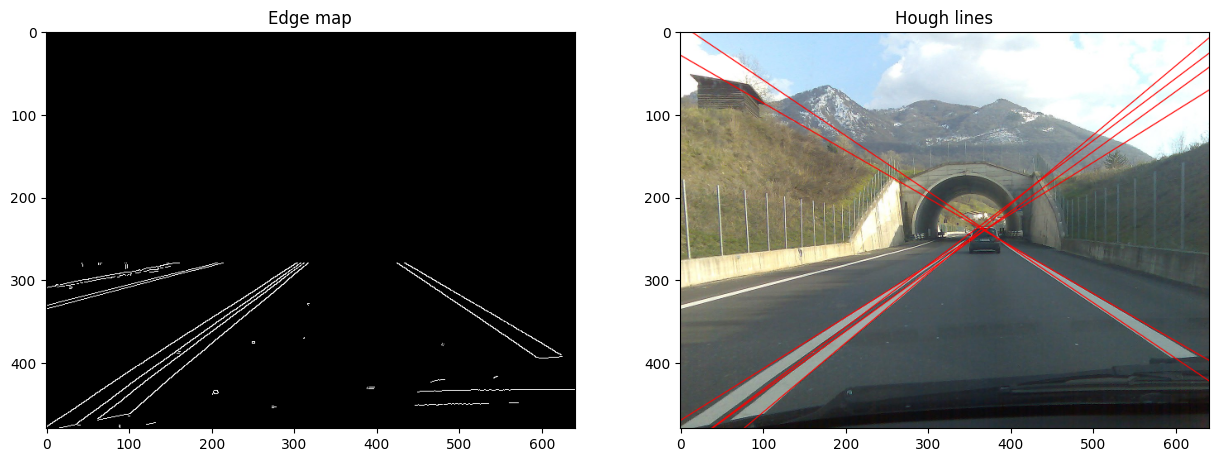

In [11]:
# Again, let's plot the resulting filtered lines
create_lines(img, kmeans.cluster_centers_, edges)

### Questions
* Do you see anything strange in the final result?
* Do you think the Hough transform resolution is important for obtaining a good result? Why?
* Do you think the Hough transform accumulator threshold is important for obtaining a good result? Why?